# 05 - Gap-edge residual correction models

This notebook introduces **gap-edge residual correction models**: a model
family that predicts a correction *on top of* linear interpolation, using
information from both edges of a gap, rather than predicting the missing
value directly from scratch.

The full fitting/leakage-control mechanics are public in
`experiments/chlorophyll/gap_edge_models.py` (feature construction) and
`experiments/chlorophyll/probabilistic_models.py` /
`coastal_gap_reconstruction.gaussian_process` (the Gaussian process and
Kalman components used by the length-routed engineered hybrid pipeline,
`experiments/chlorophyll/engineered_hybrid.py`). This notebook runs a real,
small sample of that code directly (section 7) and also loads the released,
full-449-gap comparison tables and figure for the validation-grade numbers.

It covers:

1. what a gap-edge residual correction model is;
2. why it is fundamentally retrospective, not forecast-safe;
3. how it predicts a correction over linear interpolation;
4. what features it sees;
5. when it helps and when it fails;
6. how it compares, as a classical machine-learning comparator, to the
   zero-shot TS-ICL foundation model;
7. a real, small execution of the published driver, plus the full released
   benchmark tables and figure.

## 1. What is a gap-edge residual correction model?

Linear interpolation between the last observation before a gap and the
first observation after it is already a strong baseline for short,
smooth gaps (see `03_baselines.ipynb`). A gap-edge residual correction
model starts from that same linear interpolation and learns to predict the
**residual** -- how far the true (withheld) value is likely to deviate
from the straight-line interpolation -- using extra information available
at both edges of the gap and from engineered external predictors (see
`04_engineered_tabular_models.ipynb`).

This is a different strategy from training a model to predict the target
value directly: by construction, the model only has to learn the
*correction*, which can be a smaller, easier-to-learn signal than the raw
target value, especially when interpolation is already a reasonable
starting point.

## 2. Why this approach is retrospective, not forecast-safe

A gap-edge residual model needs an observation **after** the gap (the
"post-edge" value) to compute the interpolation baseline it corrects, and
to construct several of its own input features (e.g. a post-gap rolling
summary). That means it can only be used:

- to fill an **artificial gap** in a validation experiment, where the
  surrounding real data exists and was only masked for testing, or
- to retrospectively reconstruct a **real gap** after the sensor came
  back online and post-gap data became available.

It **cannot** be used for live forecasting (predicting today's value
without knowing tomorrow's), because the post-edge information it depends
on does not exist yet in a forecasting setting. This mirrors the same
caveat already noted for plain linear interpolation in
`docs/methodology/model_families.md`, and is why this project's scope is
diagnostic reconstruction, not forecasting (see the project's top-level
scope notes).

## 3. How the correction is predicted

At a high level:

1. Compute the linear interpolation baseline for the gap (using the
   pre-edge and post-edge observed values).
2. Compute a set of gap-edge and engineered-predictor features for the
   gap (see section 4).
3. Train a regression model (e.g. ridge regression, random forest,
   gradient boosting) to predict `true_value - interpolation_baseline`
   (the residual) from those features, using gaps where the true value is
   known (i.e. artificial gaps in the validation pool).
4. At prediction time, for a new gap, compute the interpolation baseline
   and the same features, predict the residual, and add it back:
   `prediction = interpolation_baseline + predicted_residual`.

This keeps the model's job bounded: even if the residual prediction is
poor, the result degrades gracefully toward the interpolation baseline
rather than producing an arbitrary value.

**Which interpolation, exactly?** This gap-edge model's interpolation
baseline (`gap_edge_models.compute_interp`) interpolates in **physical
(mg/m^3) space** between the pre- and post-edge observations, then takes
log10 of the interpolated physical value -- this is the anchor the residual
is defined against, and it is a different formula from the package's
**standalone** `canonical_interpolation` benchmark method
(`interpolation_baselines.standalone_log10_interpolation_predictions`),
which interpolates in **log10 space** directly (matching the released
`canonical_interpolation` row in
`chlorophyll_matched_support_method_metrics.csv`). The two formulas agree
only at the two edge observations themselves and diverge at every interior
day; see the module docstring in `interpolation_baselines.py` for why both
exist and must not be substituted for each other.

## 4. What features the model sees

- **Gap-edge values** -- the last observed value before the gap and the
  first observed value after it (and possibly their difference, or
  short rolling summaries computed only from observed days adjacent to
  the gap).
- **Pre/post summaries** -- longer trailing/leading windows around the
  gap (e.g. a 7-day mean before the gap, a 7-day mean after it), which can
  indicate whether the surrounding period was unusually high or low.
- **Engineered external predictors** -- the same family of calendar,
  SST, wind, and upwelling features described in
  `04_engineered_tabular_models.ipynb`, evaluated during the gap window,
  which can indicate whether physical forcing during the gap looked
  different from the smooth interpolation would assume.
- **Gap length** -- since the reliability of interpolation (and the
  amount of new information a correction can safely add) changes with how
  long the gap is.

## 5. When it helps, and when it fails

**Helps**: longer or smoother gaps, where linear interpolation's
straight-line assumption is least accurate but the surrounding context
(pre/post edges, external forcing) is informative -- the correction model
can recover curvature or a level shift that a straight line misses.

**Fails**: gaps that hide a real event -- a bloom peak or other sharp,
short-lived spike in chlorophyll that neither the gap edges nor the
external predictors clearly signal in advance. Every method in this
benchmark, including the leading TS-ICL configuration, systematically
under-predicts high-chlorophyll event days (see
`docs/methodology/event_limitation.md` and
`results_public/chlorophyll/chlorophyll_event_performance_summary.csv`);
a gap-edge residual model is no exception, since a hidden, short-lived
spike rarely leaves a strong enough trace in the edge values or external
forcing to be predicted reliably.

## 6. A classical comparator to the zero-shot foundation model

This model family -- along with the Gaussian process and Kalman
state-space components in `probabilistic_models.py` -- forms the
"engineered hybrid pipeline" released as
`results_public/chlorophyll/chlorophyll_reconstruction_engineered_hybrid.csv`,
assembled by `experiments/chlorophyll/engineered_hybrid.py`'s length-routed
assignment rule (GP for L=1-3, Kalman for L=4-29, gap-edge residual for
L>=30). It represents a classical machine-learning approach: engineered
features, a validation-aware policy for choosing which method family to
trust at each gap length, and a fully-explainable prediction path (no
black-box foundation model in the loop).

**Known limitation, stated directly**: the Kalman component's maximum-
likelihood fit on this series is degenerate (observation-noise variance
converges to ~0), so its predictions are numerically close to plain linear
interpolation for most of the L=4-29 segment -- see
`probabilistic_models.py`'s module docstring and
`tests/test_probabilistic_models.py`'s pinned regression test for the
exact finding. This is reproduced here, not silently fixed.

TS-ICL (`06_tsicl_zero_shot_imputation.ipynb`) takes the opposite
approach: a large pretrained time-series foundation model applied with no
site-specific fine-tuning, given the gappy series (optionally with a
satellite chlorophyll proxy covariate) and asked to fill the gap directly.

Under this project's validation-grade testing
(`results_public/chlorophyll/chlorophyll_benchmark_summary.csv`,
`results_public/chlorophyll/chlorophyll_artificial_gap_scores.csv`), the
TS-ICL satellite-proxy configuration has a lower point-estimate MAE than
the engineered hybrid pipeline at every individually reported gap length
(1 through 60 days). The pooled (all-gaps) improvement is statistically
resolved: bootstrap CI on the MAE difference excludes zero
(delta -0.0169, 95% CI [-0.0244, -0.0101]). The released tables do not
include a per-length confidence interval for this specific pairwise
comparison, so "TS-ICL wins at every length" should be read as a
point-estimate/directional statement, not a length-by-length significance
claim -- the pooled-level significance is the validation-grade evidence.
The engineered hybrid pipeline remains a reasonable choice when a
no-external-dependency, non-foundation-model pipeline is preferred, but the
pooled validation evidence currently favors the zero-shot foundation model
approach in this setting.

## 7. A real, small execution, then the full released benchmark

The cell below runs the real published gap-edge driver
(`experiments/chlorophyll/gap_edge_models.py`) leave-one-gap-out on a small
sample of gaps, using the exact feature registry
(`gap_edge_models.build_feature_registry()`) -- not a re-description of it.
Full retraining of the 449-gap matched support is out of scope for an
ordinary notebook execution (it takes several minutes); reproduce it with:

```bash
python -m experiments.chlorophyll.run_classical_benchmark \
    --methods tier_ch_deployed,engineered_hybrid \
    --out build/chlorophyll/classical_benchmark
python -m experiments.chlorophyll.run_classical_benchmark --verify \
    --out build/chlorophyll/classical_benchmark
```

Section 7b then loads the already-computed, full-449/681-gap released
tables and figure for the validation-grade comparison numbers.

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd

from experiments.chlorophyll import benchmark_contract as bc
from experiments.chlorophyll import gap_edge_models as gem

target = pd.read_csv(
    "../data_public/chlorophyll/chlorophyll_daily_target.csv", parse_dates=["date"]
).set_index("date").sort_index()
features_indexed = pd.read_csv(
    "../data_public/chlorophyll/chlorophyll_predictor_features_curated.csv", parse_dates=["date"]
).set_index("date").sort_index()

registry = gem.build_feature_registry()
print(f"gap-edge feature registry: {len(registry)} entries, families = {sorted(registry['family'].unique())}")

# Context pool (L=1/L=3 matched-support gaps, ~199 gaps) supplies realistic
# leave-one-gap-out training rows; only 6 gaps are actually fit/scored here
# (score_gap_ids), keeping this cell fast without shrinking the training context.
context_pool = bc.load_matched_support_pool()[lambda df: df["gap_length"].isin([1, 3])]
sample_ids = context_pool.sample(n=6, random_state=0)["gap_id"].tolist()
preds, warns = gem.run_loco_evaluation(context_pool, target, features_indexed, score_gap_ids=sample_ids)
err = (preds["pred_log10"] - np.log10(preds["true"].clip(lower=1e-4))).abs()
print(f"6-gap sample: {len(preds)} predicted days, day-weighted MAE (log10) = {err.mean():.4f}")
print(
    "Illustrative only -- this small sample's MAE will not match the released "
    "449-gap matched-support MAE (chlorophyll_matched_support_method_metrics.csv, "
    "method_id='tier_ch_deployed')."
)

gap-edge feature registry: 40 entries, families = ['edge', 'interp', 'label', 'meta', 'post', 'pre', 'target']


6-gap sample: 14 predicted days, day-weighted MAE (log10) = 0.1162
Illustrative only -- this small sample's MAE will not match the released 449-gap matched-support MAE (chlorophyll_matched_support_method_metrics.csv, method_id='tier_ch_deployed').


In [2]:
import pandas as pd

benchmark = pd.read_csv(
    "../results_public/chlorophyll/chlorophyll_benchmark_summary.csv"
)
gap_scores = pd.read_csv(
    "../results_public/chlorophyll/chlorophyll_artificial_gap_scores.csv"
)

# Pairwise comparisons involving the engineered hybrid pipeline, all gaps.
hybrid_name = "Engineered hybrid pipeline (validation-aware method assignment)"
hybrid_rows = benchmark[
    (benchmark["method_public_name"] == hybrid_name)
    | (benchmark["compared_against_public_name"] == hybrid_name)
]
hybrid_rows[[
    "method_public_name", "compared_against_public_name", "stratum",
    "n_gaps", "method_value", "comparison_value", "delta", "interpretation",
]]

,method_public_name,compared_against_public_name,stratum,n_gaps,method_value,comparison_value,delta,interpretation
2,TS-ICL (satellite chlorophyll proxy covariate),Engineered hybrid pipeline (validation-aware m...,all_gaps,681,0.2432,0.2601,-0.0169,significant_improvement
11,Engineered hybrid pipeline (validation-aware m...,Linear interpolation baseline,all_gaps,680,0.2601,0.2706,-0.0105,significant_improvement


In [3]:
# Error by gap length for the engineered hybrid pipeline vs. TS-ICL and
# linear interpolation, using the long-format scores table.
methods_of_interest = [
    hybrid_name,
    "TS-ICL (satellite chlorophyll proxy covariate)",
    "Linear interpolation baseline",
]
by_length = gap_scores[
    (gap_scores["stratum_type"] == "gap_length")
    & (gap_scores["method_public_name"].isin(methods_of_interest))
]
pivot = by_length.pivot_table(
    index="stratum_value", columns="method_public_name", values="day_weighted_mae",
    aggfunc="mean",
)
pivot

method_public_name,Engineered hybrid pipeline (validation-aware method assignment),Linear interpolation baseline,TS-ICL (satellite chlorophyll proxy covariate)
stratum_value,,,
L=1,0.1037,0.1077,0.10595
L=10,0.2233,0.2252,0.20880
L=14,0.2523,0.2535,0.23450
L=21,0.2754,0.2747,0.25310
L=3,0.1290,0.1329,0.12220
L=30,0.2651,0.2779,0.25420
L=45,0.3173,0.3578,0.29230
L=60,0.2938,0.3094,0.27660
L=7,0.1891,0.1904,0.17960


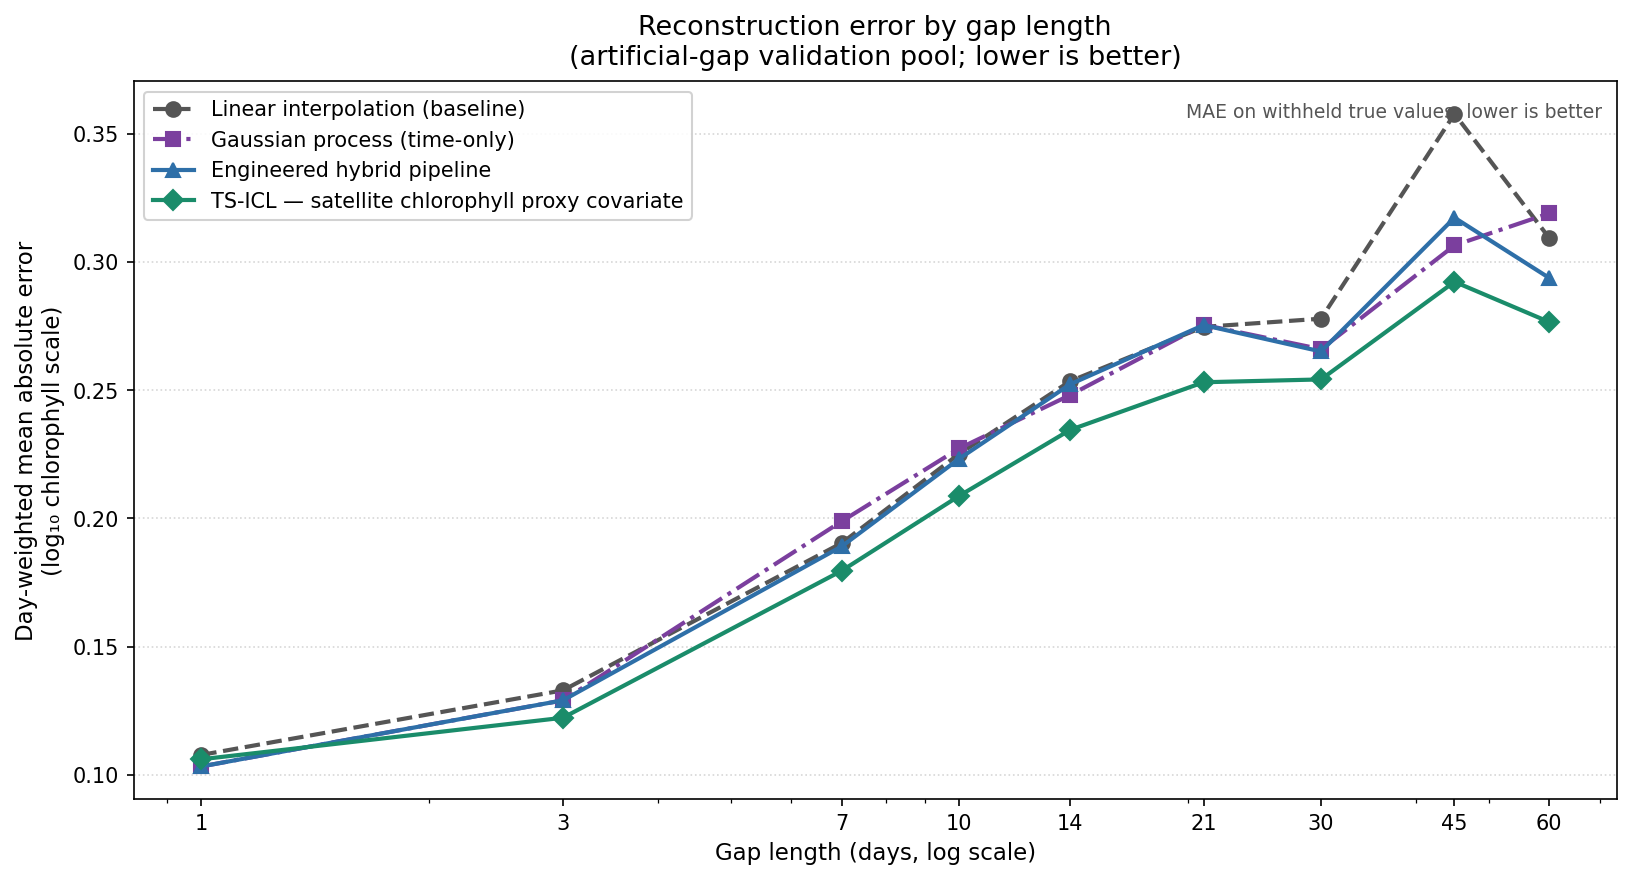

In [4]:
from PIL import Image

# The gap-length performance figure visualizes this
# length-by-length comparison across all evaluated methods.
img = Image.open("../figures/chlorophyll/figure_gap_length_performance.png")
img

## 8. Takeaways

- A gap-edge residual correction model predicts a correction over linear
  interpolation, using both gap edges, pre/post summaries, and engineered
  external predictors.
- It is retrospective by construction (it needs a post-gap observation),
  so it is only usable for artificial-gap validation or after-the-fact
  reconstruction of real gaps -- never for live forecasting.
- It tends to help most on longer/smoother gaps and tends to fail on
  hidden events (sharp, short-lived chlorophyll spikes), the same
  limitation that affects every method in this benchmark.
- As a classical machine-learning comparator to the zero-shot TS-ICL
  foundation model, it avoids depending on a foundation model, and its
  fitting/leakage-control code (`gap_edge_models.py`, `probabilistic_models.py`,
  `engineered_hybrid.py`) is public -- but the pooled validation-grade
  evidence in this benchmark currently favors TS-ICL with a satellite
  chlorophyll proxy covariate -- see
  `results_public/chlorophyll/chlorophyll_benchmark_summary.csv` and
  `docs/evidence_hierarchy.md` before drawing any stronger conclusion.